In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('csv_checkpoints/training_log_ep410.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 410 entries, 0 to 409
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   episode           410 non-null    int64  
 1   total_reward      410 non-null    float64
 2   step_count        410 non-null    int64  
 3   success           410 non-null    int64  
 4   success_rate      410 non-null    float64
 5   duration_s        410 non-null    float64
 6   epsilon           410 non-null    float64
 7   action_0_count    410 non-null    int64  
 8   action_1_count    410 non-null    int64  
 9   action_2_count    410 non-null    int64  
 10  action_3_count    410 non-null    int64  
 11  action_4_count    410 non-null    int64  
 12  action_5_count    410 non-null    int64  
 13  action_6_count    410 non-null    int64  
 14  action_7_count    410 non-null    int64  
 15  action_8_count    410 non-null    int64  
 16  action_9_count    410 non-null    int64  
 17  most_use

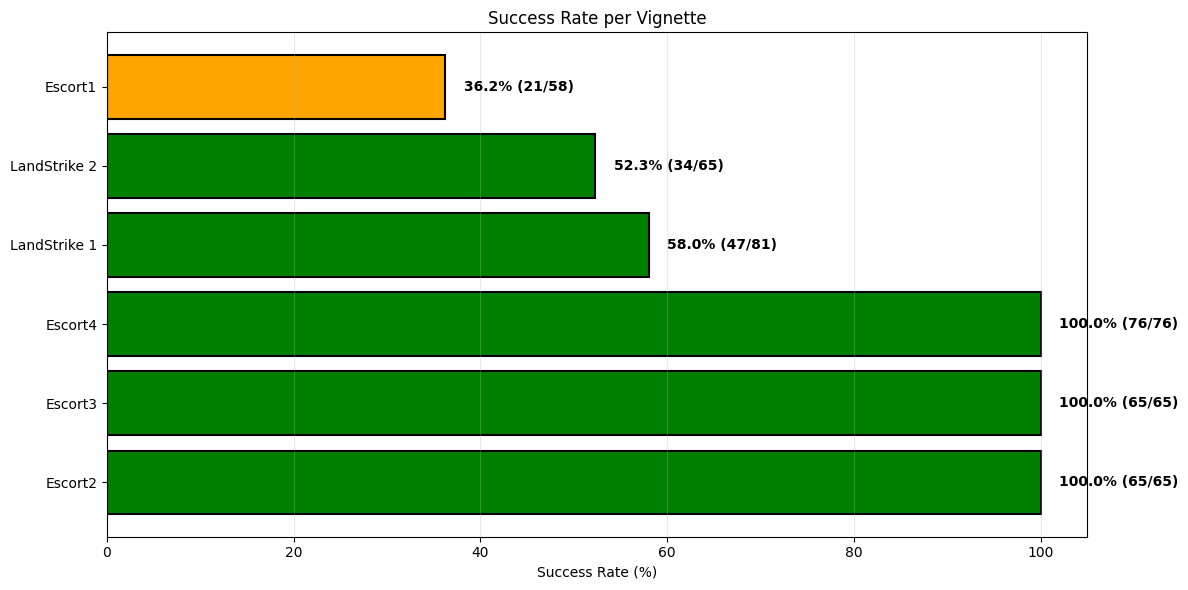


SUCCESS RATE BY VIGNETTE
    scenario  successes  total  success_rate
     Escort2         65     65    100.000000
     Escort3         65     65    100.000000
     Escort4         76     76    100.000000
LandStrike 1         47     81     58.024691
LandStrike 2         34     65     52.307692
     Escort1         21     58     36.206897


In [2]:
# Success Rate per Scenario
fig, ax = plt.subplots(figsize=(12, 6))

scenario_stats = df.groupby('scenario').agg({
    'success': ['sum', 'count']
}).reset_index()
scenario_stats.columns = ['scenario', 'successes', 'total']
scenario_stats['success_rate'] = (scenario_stats['successes'] / scenario_stats['total']) * 100
scenario_stats = scenario_stats.sort_values('success_rate', ascending=False)

colors = ['green' if x >= 50 else 'orange' for x in scenario_stats['success_rate']]
bars = ax.barh(scenario_stats['scenario'], scenario_stats['success_rate'], color=colors, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Success Rate (%)')
ax.set_title('Success Rate per Vignette')
ax.set_xlim([0, 105])
ax.grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, scenario_stats['success_rate'])):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2, f'{val:.1f}% ({int(scenario_stats.iloc[i]["successes"])}/{int(scenario_stats.iloc[i]["total"])})', 
            va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Display as table
print("\n" + "=" * 80)
print("SUCCESS RATE BY VIGNETTE")
print("=" * 80)
print(scenario_stats.to_string(index=False))

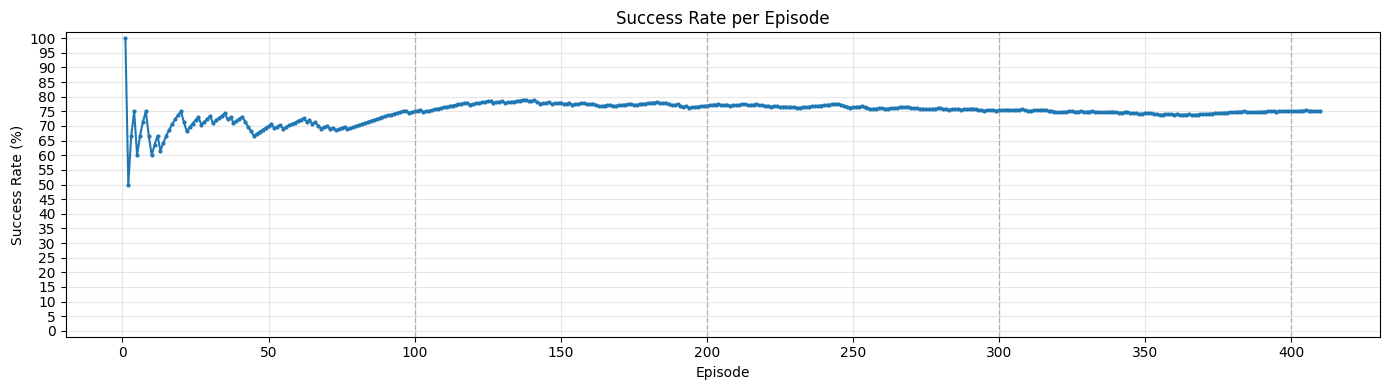


OVERALL SUCCESS RATE 
Overall Success Rate: 75.12% (308/410)


In [7]:
# Success Rate per Episode with 5% Tick Increments
plt.figure(figsize=(14, 4))
plt.plot(df['episode'], df['success_rate'] * 100, marker='o', linestyle='-', markersize=2, color='tab:blue')
for boundary in range(int((df['episode'].iloc[0] // 100 + 1) * 100), int(df['episode'].iloc[-1]) + 1, 100):
    plt.axvline(x=boundary, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.xlabel('Episode')
plt.ylabel('Success Rate (%)')
plt.title('Success Rate per Episode')
plt.yticks(np.arange(0, 101, 5))
plt.ylim([-2, 102])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("OVERALL SUCCESS RATE ")
print("=" * 80)
overall_success_rate = (df['success'].sum() / df['success'].count()) * 100
print(f"Overall Success Rate: {overall_success_rate:.2f}% ({int(df['success'].sum())}/{int(df['success'].count())})")

MOST USED ACTIONS ANALYSIS

Most Used Action per Episode (first 10 episodes):
--------------------------------------------------
Episode 1: attack_slot_3
Episode 2: attack_slot_2
Episode 3: move_to_ally
Episode 4: nothing
Episode 5: move_to_ally
Episode 6: nothing
Episode 7: radar_off
Episode 8: move_random
Episode 9: attack_slot_2
Episode 10: attack_slot_3

... (showing first 10 of 410 episodes)

OVERALL MOST USED ACTIONS ACROSS ALL EPISODES
Total usage across all episodes:
  action_0: 1145 times (5.1%)
  action_1: 4182 times (18.5%)
  action_2: 3645 times (16.1%)
  action_3: 2176 times (9.6%)
  action_4: 950 times (4.2%)
  action_5: 931 times (4.1%)
  action_6: 932 times (4.1%)
  action_7: 2538 times (11.2%)
  action_8: 2307 times (10.2%)
  action_9: 3842 times (17.0%)

Most used action overall: action_1_count (4182 times)


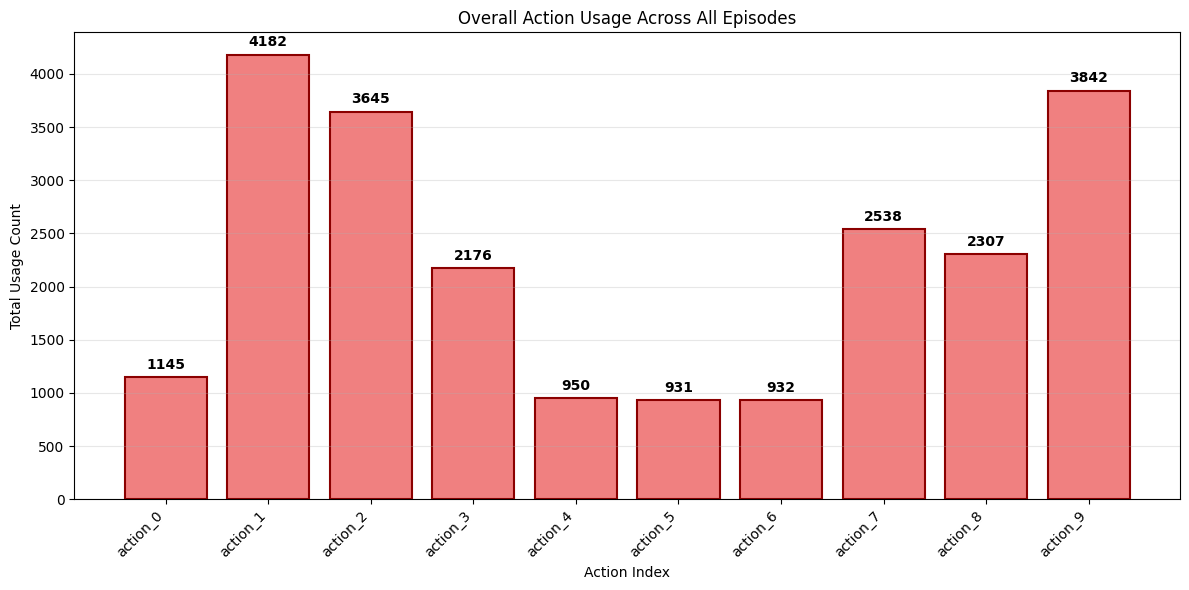

In [4]:
# Most Used Actions Analysis
print("=" * 80)
print("MOST USED ACTIONS ANALYSIS")
print("=" * 80)

# Most used action per episode (first 10 episodes)
print("\nMost Used Action per Episode (first 10 episodes):")
print("-" * 50)
for idx, row in df.head(10).iterrows():
    print(f"Episode {int(row['episode'])}: {row['most_used_action']}")

print(f"\n... (showing first 10 of {len(df)} episodes)")

# Overall most used actions across all episodes
print("\n" + "=" * 60)
print("OVERALL MOST USED ACTIONS ACROSS ALL EPISODES")
print("=" * 60)

action_columns = [f'action_{i}_count' for i in range(10)]
action_totals = df[action_columns].sum()

print("Total usage across all episodes:")
for i, total in enumerate(action_totals):
    percentage = (total / action_totals.sum()) * 100
    print(f"  action_{i}: {int(total)} times ({percentage:.1f}%)")

most_used_idx = action_totals.idxmax()
print(f"\nMost used action overall: {most_used_idx} ({int(action_totals.max())} times)")

# Visualize overall action usage
plt.figure(figsize=(12, 6))
bars = plt.bar(range(10), action_totals, color='lightcoral', edgecolor='darkred', linewidth=1.5)
plt.xlabel('Action Index')
plt.ylabel('Total Usage Count')
plt.title('Overall Action Usage Across All Episodes')
plt.xticks(range(10), [f'action_{i}' for i in range(10)], rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, action_totals)):
    plt.text(bar.get_x() + bar.get_width()/2, val + 50, f'{int(val)}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

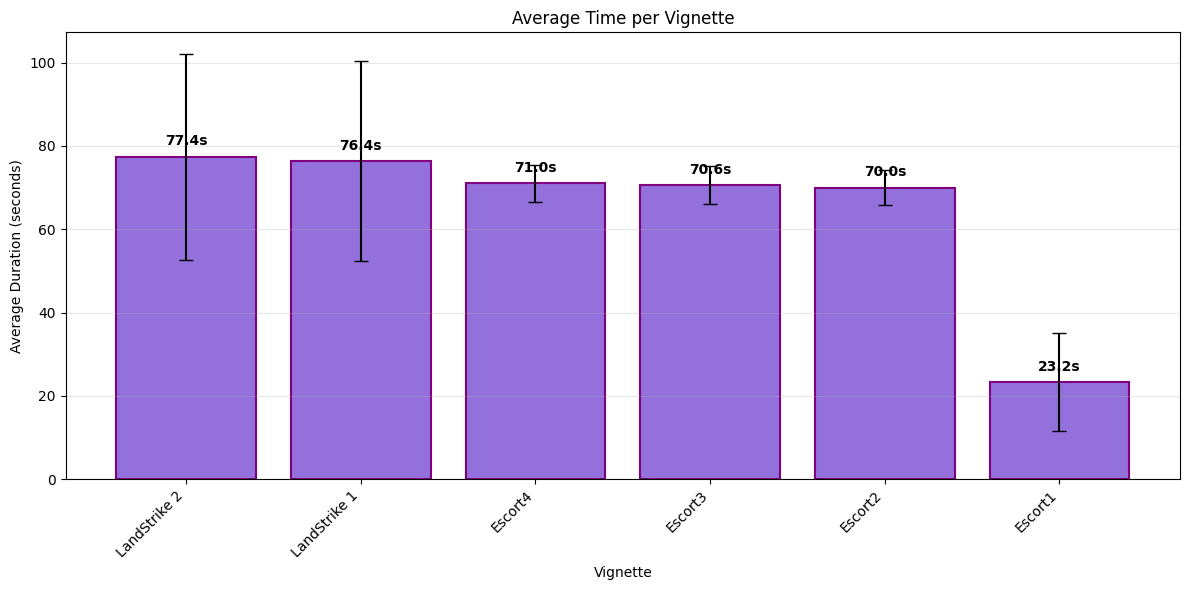


AVERAGE TIME BY VIGNETTE
    scenario    max      mean   min       std  count
LandStrike 2 105.43 77.398308 35.72 24.775122     65
LandStrike 1 116.05 76.388025 35.74 24.108114     81
     Escort4  81.97 71.030921 66.18  4.408911     76
     Escort3  81.86 70.604462 66.19  4.487713     65
     Escort2  80.96 69.994154 66.11  4.126242     65
     Escort1  75.34 23.246379 14.26 11.765035     58


In [5]:
# Average Time per Scenario
fig, ax = plt.subplots(figsize=(12, 6))

time_per_scenario = df.groupby('scenario')['duration_s'].agg(['max','mean', 'min', 'std', 'count']).reset_index()
time_per_scenario = time_per_scenario.sort_values('mean', ascending=False)

bars = ax.bar(range(len(time_per_scenario)), time_per_scenario['mean'], 
              color='mediumpurple', edgecolor='purple', linewidth=1.5,
              yerr=time_per_scenario['std'], capsize=5)
ax.set_ylabel('Average Duration (seconds)')
ax.set_xlabel('Vignette')
ax.set_title('Average Time per Vignette')
ax.set_xticks(range(len(time_per_scenario)))
ax.set_xticklabels(time_per_scenario['scenario'], rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, time_per_scenario['mean'])):
    ax.text(bar.get_x() + bar.get_width()/2, val + 2, f'{val:.1f}s', 
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Display as table
print("\n" + "=" * 80)
print("AVERAGE TIME BY VIGNETTE")
print("=" * 80)
print(time_per_scenario.to_string(index=False))